# Tumor compostion and reucrance time

A key determinate of the time to recurrence is the subpopulation composition at the end of therapy.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.tri as tri
from matplotlib.patches import Wedge

import gsc_model_functions as gmf

In [2]:
def generate_ICs(total_IC,n):
    # First IC 100% GSCs
    u0 = np.zeros(n+1)
    u0[0] = total_IC

    # Second IC 50% GSCs, 40% PCs and 10% TDCs
    u0_1 = np.zeros(n+1)
    u0_1[0] = total_IC * 0.5
    u0_1[1:-1] = total_IC * 0.4 / (n-1)
    u0_1[-1] = total_IC * 0.1

    # third IC 10% GSCs, 60% PCs and 30% TDCs
    u0_2 = np.zeros(n+1)
    u0_2[0] = total_IC * 0.1
    u0_2[1:-1] = total_IC * 0.6 / (n-1)
    u0_2[-1] = total_IC * 0.3

    return u0, u0_1, u0_2

In [3]:
# parameter values for all model simulation
dt = 0.2
t_end = 30 # days, max time we will simulate for.


n = 10 
r = np.zeros(n)
r[0] = 1
Ps = 0.52
k = 1
ms = 0.2 
mv = np.ones(n)*0.4
mv[-1] = 0
delta_s = 0.001
delta_v = np.ones(n)*0.05

# total IC size
total_IC = 0.01 # 1% of carrying capacity


In [4]:


# simulate model with given IC until t_end days
def time_to_growth(IC, t_end, n=n, Ps=Ps, k=k, ms=ms, mv=mv, delta_s=delta_s, delta_v=delta_v, r=r):

    t,u = gmf.simulate_simple(t_end,dt,IC,n,Ps,k,ms,mv,delta_s,delta_v,r)

    return np.sum(u[-1,:])

# simulate model for a fixed time and return the time at which it reaches a certain size (0.1 in this case). if the size is never reach reutrn nan
def time_to_size(IC, t_end, n=n, Ps=Ps, k=k, ms=ms, mv=mv, delta_s=delta_s, delta_v=delta_v, r=r):

    t,u = gmf.simulate_simple(t_end,dt,IC,n,Ps,k,ms,mv,delta_s,delta_v,r)

    for i in range(len(t)):
        if np.sum(u[i,:]) >= 0.1:
            return t[i]

    return np.nan

# produce the IC based on the compositon fractions
def calc_IC(compositions, total_IC,n=10):

    u0 = np.zeros(n+1)
    u0[0] = compositions[0] * total_IC
    u0[1:-1] = compositions[1] * total_IC / (n-1)
    u0[-1] = compositions[2] * total_IC

    return u0

# swith from composition fractions to ternary plot coords
def composition_to_coords(comp):
    gsc_frac = comp[0]
    pc_frac = comp[1]
    tdc_frac = comp[2]

    x = pc_frac + 0.5 * tdc_frac
    y = (np.sqrt(3)/2) * tdc_frac

    return np.array([x, y])

In [5]:
# create a triangle mesh grid of IC compositions
N = 100   # resolution
compositions = []

for i in range(N+1):
    for j in range(N+1-i):
        GSC = i / N
        PC = j / N
        TDC = 1 - GSC - PC
        compositions.append((GSC, PC, TDC))

compositions = np.array(compositions)

GSCs = compositions[:,0] 
PCs = compositions[:,1] 
TDCs = compositions[:,2] 


# Calulate size at t_end for each composition
ms_vals = np.array([0.4/2,0.4/10,0.4/100])
#ms = 0.2
#mV_vals = np.array([0.4,4,10])
Ps_vals = np.array([0.52,0.7,0.95])
Tvals_300 = np.zeros((len(compositions), len(ms_vals), len(Ps_vals)))

for i in range(len(compositions)):
    for j in range(len(ms_vals)):
        for q in range(len(Ps_vals)):
            ms = ms_vals[j]
            Ps = Ps_vals[q]
            IC = calc_IC(compositions[i], total_IC)
            #Tvals_300[i,j,q] = time_to_growth(IC, t_end, ms=ms, Ps=Ps)
            Tvals_300[i,j,q] = time_to_size(IC, t_end, ms=ms, Ps=Ps)

In [6]:
chars = ['a', 'b', 'c']

def add_coords(ax, comp, label, col = 'red'):
    x, y = composition_to_coords(comp)
    ax.plot(x, y, 'o', color=col)  # plot the point
    ax.text(x, y+0.03, label, color=col, ha='center')  # add label above the point



def make_tri_contour_plot(Tvals_300,ax, title = "", coors = np.array([[1,0,0],[0.5,0.4,0.1],[0.1,0.6,0.3]]), add_coords_labs=False, col = 'red'):
    x = PCs + 0.5 * TDCs
    y = np.sqrt(3)/2 * TDCs

    mask = mask = ~np.isnan(Tvals_300)

    triang = tri.Triangulation(x[mask], y[mask])


    cntr = ax.tricontourf(triang, Tvals_300[mask], levels=10, cmap='viridis')
    #plt.triplot(triang, 'ko-', alpha=0.3, markersize=2)
    #ax.colorbar(cntr, label="Size at $t = {}$ days".format(t_end), shrink=0.8)

    # draw triangle boundary
    ax.plot([0, 1, 0.5, 0], [0, 0, np.sqrt(3)/2, 0], 'k-', lw=1)

    #ax.axis('equal')
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')

    # add labels
    ax.text(0, -0.07, 'CSCs', ha='center')
    ax.text(1, -0.07, 'PCs', ha='center')
    ax.text(0.5, np.sqrt(3)/2 + 0.01, 'TDCs', ha='center')

    # Add text labels for where the virtual tumors are
    # get A coordinates

    if add_coords_labs:
        for i in range(len(coors)):
            add_coords(ax, coors[i], chars[i], col=col)

        
    ax.set_xlim(-0.05, 1)
    ax.set_ylim(-0.05, np.sqrt(3)/2 + 0.05)

    ax.set_title(title)

    return cntr

In [7]:
# --- Helper: draw pie chart at (x,y) ---
def draw_pie(ax, center, sizes, colors, radius=0.05, start_angle=90):
    angle = start_angle  # degrees; 90 = straight up
    for size, color in zip(sizes, colors):

        if size == 0: # if conponent is 0 then do not plot it
            continue
        
        theta1 = angle
        theta2 = angle + size * 360
        ax.add_patch(Wedge(center, radius, theta1, theta2,
                           facecolor=color, edgecolor='k'))
        angle = theta2


# create arrow that goes from a give edge to a given location (center) and stops before the center by a given radius (pie_radius)
def perpendicular_arrow_to_center(p1, p2, center, pie_radius=0.05):
    # edge vector
    e = p2 - p1
    
    # project center onto edge → foot of perpendicular
    s = np.dot(center - p1, e) / np.dot(e, e)
    
    # optional: keep it on the edge segment
    s = np.clip(s, 0, 1)
    
    foot = p1 + s * e
    
    # direction toward center
    direction = center - foot
    direction = direction / np.linalg.norm(direction)
    
    # stop before pie chart
    end = center - pie_radius * direction
    
    return foot, end

def make_demo_plot(ax):
    ax.axis('off')
    ax.set_aspect('equal', adjustable='box')

    # Triangle vertices
    A = np.array([0, 0])
    B = np.array([1, 0])
    C = np.array([0.5, np.sqrt(3)/2])

    # --- Draw triangle ---
    triangle = np.array([A, B, C, A])
    ax.plot(triangle[:, 0], triangle[:, 1], 'k')

    # --- Colors for components ---
    colors = ['red', 'orange', 'green']
    # --- Corner pies (100%) ---
    draw_pie(ax, A, [1, 0, 0], colors)
    draw_pie(ax, B, [0, 1, 0], colors)
    draw_pie(ax, C, [0, 0, 1], colors)

    # example composition roghly in the center of plot
    eg_com = np.array([0.4,0.25,0.35])
    xy_coords = composition_to_coords(eg_com)
    draw_pie(ax,xy_coords, eg_com, colors)


    # add arrows 
    edges = [(B, C), (C, A),(A, B) ]

    for i, (p1, p2) in enumerate(edges):
        start, end = perpendicular_arrow_to_center(p1, p2, xy_coords)

        # add small box to indicate 90 degrees
        box_size = 0.05
        box_center = start 
        box = plt.Rectangle((box_center[0], box_center[1] ),
                            box_size, box_size, angle=np.rad2deg(np.arctan2(end[1]-start[1], end[0]-start[0])), 
                            facecolor='none', edgecolor='k')
        ax.add_patch(box)
        
        ax.arrow(start[0], start[1],
                end[0] - start[0],
                end[1] - start[1],
                fc=colors[i], ec='none',
                width=0.005,
                head_width=0.03,
                head_length=0.02,
                length_includes_head=True)
        


    # label the destination point # this is too small to see when its part of subplot
    #ax.text(xy_coords[0]+0.22, xy_coords[1] - 0.01, '$\mathbf{x} = [0.4,0.25,0.35]$', ha='center', fontsize=4)

    # label the corners
    ax.text(-0.1,0.07, 'CSCs', ha='center', fontsize=12)
    ax.text(1.07,0.07, 'PCs', ha='center', fontsize=12)
    ax.text(0.5,np.sqrt(3)/2+0.07, 'TDCs', ha='center', fontsize=12)

    # label the arrows
    ax.text(0.57, 0.44, '$x_1$', ha='center', fontsize=10, color = colors[0])
    ax.text(0.29, 0.31, '$x_2$', ha='center', fontsize=10,color = colors[1])
    ax.text(0.37, 0.12, '$x_3$', ha='center', fontsize=10,color = colors[2])


In [8]:
ABC = np.array([[1,0,0], [0.5,0.4,0.1], [0.1,0.6,0.3]])
for i, comp in enumerate(ABC):
    IC = calc_IC(comp, total_IC)
    t, u = gmf.simulate_simple(t_end, dt, IC, n, Ps_vals[1], k, ms_vals[1], mv, delta_s, delta_v, r)
    total = np.sum(u, axis=1)

    hit = np.where(total >= 0.1)[0]
    t_hit = t[hit[0]] if len(hit) else np.nan

    idx = np.where(np.all(np.isclose(compositions, comp), axis=1))[0][0]
    print(i, "time_to_size(sim)=", t_hit, "Tvals_300=", Tvals_300[idx, 1, 1], "max=", total.max())

0 time_to_size(sim)= 16.400000000000002 Tvals_300= 16.400000000000002 max= 0.34057223193284497
1 time_to_size(sim)= 13.8 Tvals_300= 13.8 max= 0.2581730330943302
2 time_to_size(sim)= 12.600000000000001 Tvals_300= 12.600000000000001 max= 0.17459813920451817


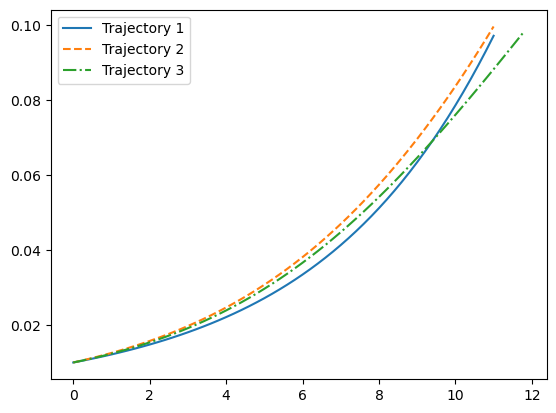

In [9]:
ABC = np.array([[1,0,0],[0.5,0.4,0.1],[0.1,0.6,0.3]])

for i in range(len(ABC)):
    IC = calc_IC(ABC[i], total_IC)
    t,u = gmf.simulate_simple(t_end,dt,IC,n,Ps,k,ms_vals[0],mv,delta_s,delta_v,r)
    u = np.sum(u, axis=1)
    u = u[u<=0.1]
    t = t[:len(u)]
    plt.plot(t, u, label = 'Trajectory {}'.format(i+1), linestyle = ['-','--','-.'][i])

plt.legend()

9.0 29.0
9.0 29.0
9.0 29.0
9.0 29.0
9.0 29.0
9.0 29.0
9.0 29.0
9.75 24.75
9.75 23.25


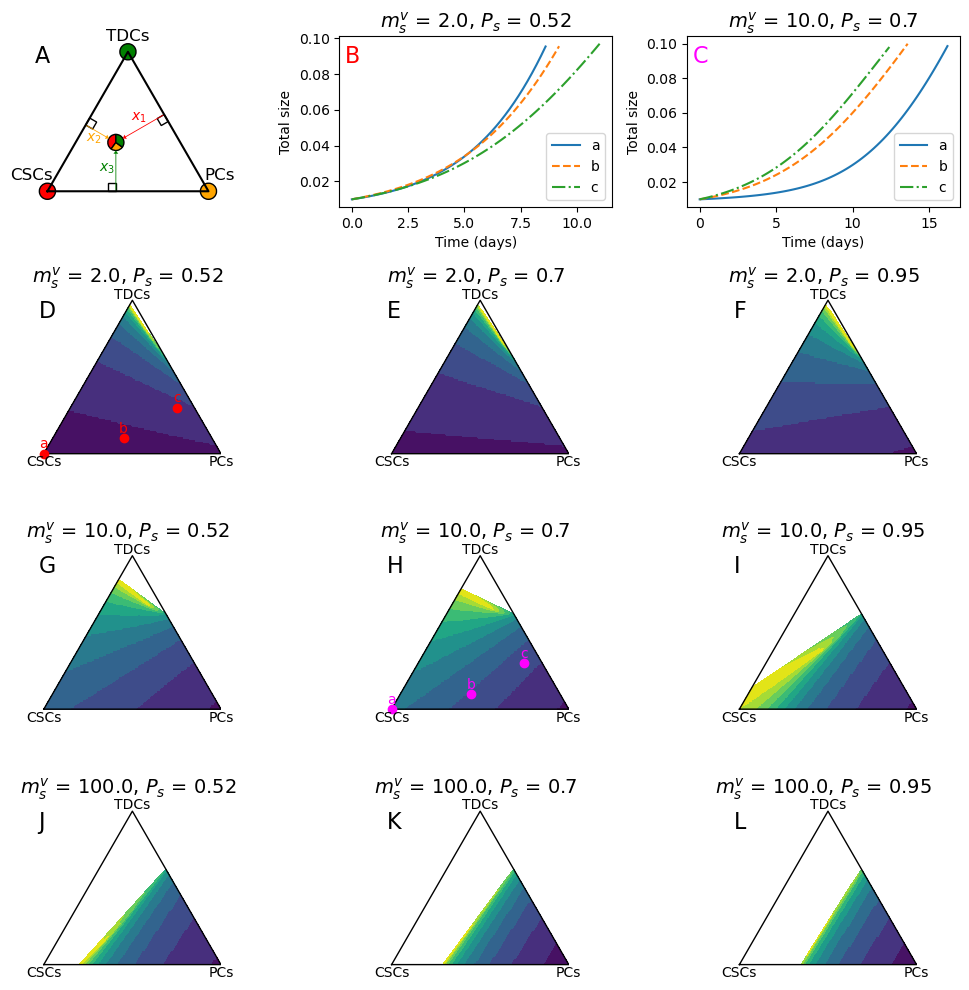

In [11]:
fig,ax = plt.subplots(4,3, figsize = (10,10))
#ax = ax.flatten()

make_demo_plot(ax[0,0])

add_coords_labs = False
col = 'black'

for i in range(len(ms_vals)):
    for j in range(len(Ps_vals)):

        # only add cordinate to specified subplots
        if i==0 and j==0:
            add_coords_labs = True
            col = 'red'
        elif i==1 and j==1:
            add_coords_labs = True
            col = 'magenta'
        else:
            add_coords_labs = False

        cntr = make_tri_contour_plot(Tvals_300[:,i,j],ax[i+1,j], add_coords_labs=add_coords_labs, col=col)
        ax[i+1,j].set_title(f'$m^v_s$ = {mv[0]/ms_vals[i]}, $P_s$ = {Ps_vals[j]}', fontsize=14)
        print(cntr.get_array().min(), cntr.get_array().max())


# add A,B,C ect. labels left to right, top to bottom
for i in range(len(ax[:,0])):
    for j in range(len(ax[0,:])):

        if i ==0 and j ==1:
            ax[i,j].text(0.02, 0.95, f'{chr(65+j + i*3)}', transform=ax[i,j].transAxes, fontsize=16, va='top', color='red')
        elif i ==0 and j ==2:
            ax[i,j].text(0.02, 0.95, f'{chr(65+j + i*3)}', transform=ax[i,j].transAxes, fontsize=16, va='top', color='magenta')
        else:
            ax[i,j].text(0.02, 0.95, f'{chr(65+j + i*3)}', transform=ax[i,j].transAxes, fontsize=16, va='top')



# get some actual trajectories to plot on top of the demo plot
ls_ = ['-', '--', '-.']
labs = ['a', 'b', 'c']
for i in range(len(ABC)):
    IC = calc_IC(ABC[i], total_IC)
    t,u = gmf.simulate_simple(t_end,dt,IC,n,Ps_vals[0],k,ms_vals[0],mv,delta_s,delta_v,r)
    u = np.sum(u, axis=1)
    u = u[u<=0.1]
    t = t[:len(u)]
    ax[0,1].plot(t, u, linestyle = ls_[i], label = labs[i])

ax[0,1].legend()
ax[0,1].set_title(f'$m^v_s$ = {mv[0]/ms_vals[0]}, $P_s$ = {Ps_vals[0]}', fontsize=14)
ax[0,1].set_xlabel('Time (days)')
ax[0,1].set_ylabel('Total size')

for i in range(len(ABC)):
    IC = calc_IC(ABC[i], total_IC)
    t,u = gmf.simulate_simple(t_end,dt,IC,n,Ps_vals[1],k,ms_vals[1],mv,delta_s,delta_v,r)
    u = np.sum(u, axis=1)
    u = u[u<=0.1]
    t = t[:len(u)]
    ax[0,2].plot(t, u, linestyle = ls_[i], label = labs[i])

ax[0,2].legend()
ax[0,2].set_title(f'$m^v_s$ = {mv[1]/ms_vals[1]}, $P_s$ = {Ps_vals[1]}', fontsize=14)
ax[0,2].set_xlabel('Time (days)')
ax[0,2].set_ylabel('Total size')


plt.tight_layout()
plt.savefig('Figs/triangle.pdf', bbox_inches='tight')
#plt.savefig('Figs/svg/triangle.svg', bbox_inches='tight')

plt.show()

In [12]:

# First IC 100% GSCs
u0 = np.zeros(n+1)
u0[0] = total_IC

# Second IC 50% GSCs, 40% PCs and 10% TDCs
u0_1 = np.zeros(n+1)
u0_1[0] = total_IC * 0.5
u0_1[1:-1] = total_IC * 0.4 / (n-1)
u0_1[-1] = total_IC * 0.1

# third IC 10% GSCs, 60% PCs and 30% TDCs
u0_2 = np.zeros(n+1)
u0_2[0] = total_IC * 0.1
u0_2[1:-1] = total_IC * 0.6 / (n-1)
u0_2[-1] = total_IC * 0.3




t,u = gmf.simulate_simple(t_end,dt,u0,n,Ps,k,ms,mv,delta_s,delta_v,r)
t,u1 = gmf.simulate_simple(t_end,dt,u0_1,n,Ps,k,ms,mv,delta_s,delta_v,r)
t,u2 = gmf.simulate_simple(t_end,dt,u0_2,n,Ps,k,ms,mv,delta_s,delta_v,r)

In [13]:
def label_wedges(ax, wedges, labels, r_frac=0.75, fontsize=10):
    for w, lab in zip(wedges, labels):

        if w.theta1 - w.theta2 == 0:
            continue
        else:

            theta = 0.5 * (w.theta1 + w.theta2)
            theta = np.deg2rad(theta)

            r = r_frac * w.r
            x = r * np.cos(theta)
            y = r * np.sin(theta)

            ax.text(x, y, lab, ha='center', va='center', fontsize=fontsize)

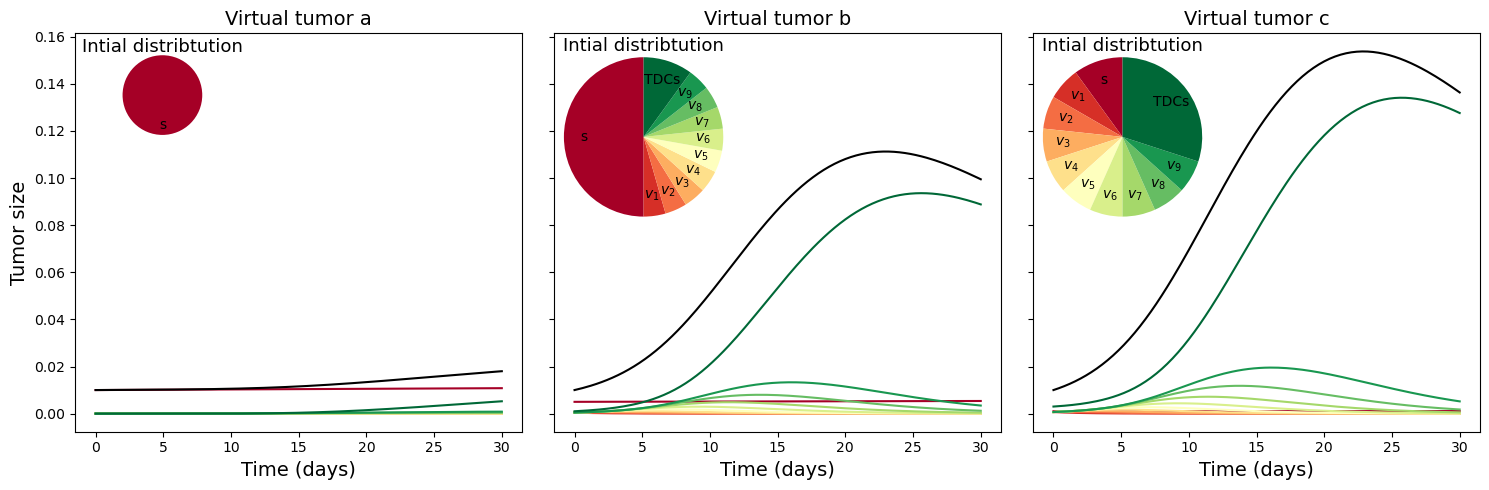

In [14]:
fig, ax = plt.subplots(1,3, figsize = (15, 5), sharey='row')


gmf.plot_all_compartments(t,u,ax[0])
gmf.plot_all_compartments(t,u1,ax[1])
gmf.plot_all_compartments(t,u2, ax[2])

# Inset pie chart for first IC

# Pie chars for compotion of IC
labels = ['s', '$v_1$', '$v_2$', '$v_3$', '$v_4$', '$v_5$', '$v_6$', '$v_7$', '$v_8$','$v_9$', 'TDCs']
# Colors from red to green
cmap = plt.get_cmap('RdYlGn')
# Interpolated colors at these positions
col = [cmap(i) for i in np.linspace(0, 1, n+1)]


ax0_in = ax[0].inset_axes([0.07, 0.72, 0.25, 0.25])
ax1_in = ax[1].inset_axes([-0.05, 0.49, 0.5, 0.5])
ax2_in = ax[2].inset_axes([-0.05, 0.49, 0.5, 0.5])

wedges0, _  = ax0_in.pie(u0[0:1], colors=col, startangle=90) # this random fix/hack is because otherwise when i save to pdf there is a small sliver of white showing the 0 compartments
wedges1, _  = ax1_in.pie(u0_1, colors=col, startangle=90)
wedges2, _  = ax2_in.pie(u0_2, colors=col, startangle=90)

label_wedges(ax0_in, wedges0, labels)
label_wedges(ax1_in, wedges1, labels)
label_wedges(ax2_in, wedges2, labels)

# titels to pie charts
ax2_in.set_title('Intial distribtution', fontsize=13, y =1, pad= -10)
ax1_in.set_title('Intial distribtution', fontsize=13, y= 1, pad = -10)
ax0_in.set_title('Intial distribtution', fontsize=13, y= 1, pad = -5)

ax[0].set_title('Virtual tumor a', fontsize=14)
ax[1].set_title('Virtual tumor b', fontsize=14)
ax[2].set_title('Virtual tumor c', fontsize=14)

ax[0].set_xlabel('Time (days)', fontsize = 14)
ax[1].set_xlabel('Time (days)', fontsize = 14)
ax[2].set_xlabel('Time (days)', fontsize = 14)

ax[0].set_ylabel('Tumor size', fontsize = 14)

plt.tight_layout()
plt.savefig('Figs/recurrence_composition.pdf', bbox_inches='tight')
plt.show()

In [15]:
# --- Helper: draw pie chart at (x,y) ---
from matplotlib.patches import Wedge


def draw_pie(ax, center, sizes, colors, radius=0.05, start_angle=90):
    angle = start_angle  # degrees; 90 = straight up
    for size, color in zip(sizes, colors):

        if size == 0: # if conponent is 0 then do not plot it
            continue
        
        theta1 = angle
        theta2 = angle + size * 360
        ax.add_patch(Wedge(center, radius, theta1, theta2,
                           facecolor=color, edgecolor='k'))
        angle = theta2


# create arrow that goes from a give edge to a given location (center) and stops before the center by a given radius (pie_radius)
def perpendicular_arrow_to_center(p1, p2, center, pie_radius=0.05):
    # edge vector
    e = p2 - p1
    
    # project center onto edge → foot of perpendicular
    s = np.dot(center - p1, e) / np.dot(e, e)
    
    # optional: keep it on the edge segment
    s = np.clip(s, 0, 1)
    
    foot = p1 + s * e
    
    # direction toward center
    direction = center - foot
    direction = direction / np.linalg.norm(direction)
    
    # stop before pie chart
    end = center - pie_radius * direction
    
    return foot, end

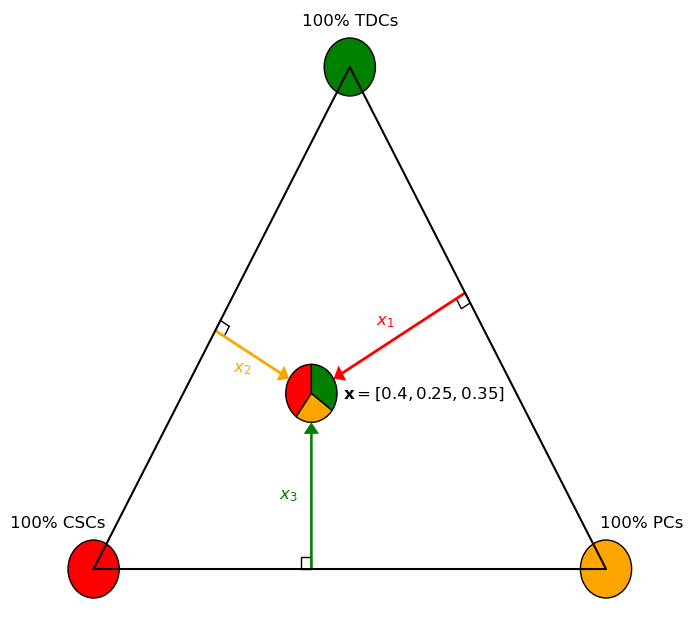

In [16]:
# --- Create figure ---
fig, ax = plt.subplots(figsize=(8, 8))

ax.axis('off')

# Triangle vertices
A = np.array([0, 0])
B = np.array([1, 0])
C = np.array([0.5, np.sqrt(3)/2])

# --- Draw triangle ---
triangle = np.array([A, B, C, A])
ax.plot(triangle[:, 0], triangle[:, 1], 'k')

# --- Colors for components ---
colors = ['red', 'orange', 'green']
# --- Corner pies (100%) ---
draw_pie(ax, A, [1, 0, 0], colors)
draw_pie(ax, B, [0, 1, 0], colors)
draw_pie(ax, C, [0, 0, 1], colors)

# example composition roghly in the center of plot
eg_com = np.array([0.4,0.25,0.35])
xy_coords = composition_to_coords(eg_com)
draw_pie(ax,xy_coords, eg_com, colors)


# add arrows 
edges = [(B, C), (C, A),(A, B) ]

for i, (p1, p2) in enumerate(edges):
    start, end = perpendicular_arrow_to_center(p1, p2, xy_coords)

    # add small box to indicate 90 degrees
    box_size = 0.02
    box_center = start 
    box = plt.Rectangle((box_center[0], box_center[1] ),
                        box_size, box_size, angle=np.rad2deg(np.arctan2(end[1]-start[1], end[0]-start[0])), 
                        facecolor='none', edgecolor='k')
    ax.add_patch(box)
    
    ax.arrow(start[0], start[1],
             end[0] - start[0],
             end[1] - start[1],
             fc=colors[i], ec='none',
             width=0.005,
             head_width=0.03,
             head_length=0.02,
             length_includes_head=True)
    


# label the destination point
ax.text(xy_coords[0]+0.22, xy_coords[1] - 0.01, '$\mathbf{x} = [0.4,0.25,0.35]$', ha='center', fontsize=12)

# label the corners
ax.text(-0.07,0.07, '100% CSCs', ha='center', fontsize=12)
ax.text(1.07,0.07, '100% PCs', ha='center', fontsize=12)
ax.text(0.5,np.sqrt(3)/2+0.07, '100% TDCs', ha='center', fontsize=12)

# label the arrows
ax.text(0.57, 0.42, '$x_1$', ha='center', fontsize=12, color = colors[0])
ax.text(0.29, 0.34, '$x_2$', ha='center', fontsize=12,color = colors[1])
ax.text(0.38, 0.12, '$x_3$', ha='center', fontsize=12,color = colors[2])


plt.savefig('Figs/trilinear_coordinates.pdf', bbox_inches='tight')
plt.show()